<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/My_Model_SImulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
from scipy.integrate import odeint

# Custom imports that are either local or pulled from github

Custom imports that are either local or pulled from github

In [8]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

Fetching from: 
<Response [200]>


# Imports related to model predictive control and pybounds

In [9]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 4.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-spwgeogy
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-spwgeogy
  Resolved https://github.com/vanbreugel-lab/pybounds to commit 96f12039ac9e1e3ef4381cd09a026f6bbf70ad5c
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19546 sha256=600634fff8a99afd70f1fe3b640585c5f9fa354af3e34ce3178ce4888276d0f5
  Stored in directory: /tmp/pip-ephem-wheel-cache-big7hav5/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Set some constant parameters (the blue symbols above)

In [10]:
Lambda = 9.04e-5    #Recuirtment rate per day
mu = 3.2e-5         #Mortility rate per day
gamma = 0.00555     #Removal rate per day

#Dynamic Function

In [18]:
def f(x_vec, u_vec, Lambda=Lambda, mu=mu, gamma=gamma):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (6,)
        State vector [S, V, I, R, beta, sigma]
    u_vec : array-like, shape (2,)
        Control vector [alpha, kappa]
    Lambda : float, default 9.04e-5
        recuirtment rate per day
    mu : float, default 3.2e-5
        mortility rate per day
    gamma : float, default
        removal rate per day
    Returns:
    x_dot : numpy array, shape (6,)
        Time derivative of state vector
    """

    # Extract state variables
    S = x_vec[0]
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]
    beta = x_vec[4]
    sigma = x_vec[5]


    # Extract control inputs
    alpha = u_vec[0]
    kappa = u_vec[1]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ Lambda - beta * S * I - mu * S,
                                 -sigma * beta * V * I - mu * V,
                                 beta*S*I + sigma*beta*V*I - gamma*I - mu*I,
                                 gamma*I - mu*R,
                                 0,
                                 0])

    # f1 component: multiplied by control alpha
    f1_contribution = alpha * np.array([-S,
                                     S,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control kappa
    f2_contribution = kappa * np.array([beta*S*I,
                                     sigma*beta*V*I,
                                     -beta*S*I - sigma*beta*V*I,
                                     0,
                                     0,
                                     0])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution

    return x_dot_vec

# Make sure dynamics make sense using odeint

Use odeint to perform a simple ODE solver using a simple controller to verify that the dynamics appear to be correct.  

In [19]:
def f_ode(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (6,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (6,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)
    return x_dot_vec

In [20]:
def u_func(x_vec, tsim):
    '''
    Controller for vaccination rate (alpha) and vaccine efficacy (kappa).

    Parameters:
    x_vec : array-like, shape (6,)
        Augmented state vector [S, V, I, R, beta, sigma]
    tsim : float
        Current simulation time

    Returns:
    u_vec : list, shape (2,)
        Control vector [alpha, kappa]
    '''
    # Extract infected population
    I = x_vec[2]

    # Simple proportional controller on infected population
    I_des = 0.01  # Desired infected proportion
    err_I = I_des - I

    # Vaccination rate control (alpha) - bounded between 0 and 0.1
    alpha = max(0, min(0.1, 0.5 * err_I))

    # Vaccine efficacy control (kappa)
    kappa = 0.8

    return [alpha, kappa]

In [21]:
# sim time
dt = 1.0  # 1 day (standard for disease models)
tsim = np.arange(0, 365, step=dt)  # 1 year

In [22]:
x0 = np.array([
    222639000,   # S susceptible
    158330000,   # V 71% of total population
    361000,      # I infected
    12000000,    # R recovered
    0.3,         # beta: transmission rate (estimate)
    0.8          # sigma: vaccine effectiveness (estimate)
])

In [23]:
# run odeint
result = odeint(f_ode, x0, tsim, args=(u_func, f) )

#Total population

In [29]:
N = 223000000

# DIsease Measurements
$
\mathbf{y} =
\begin{bmatrix}
0.6\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{V}/N
\end{bmatrix}
$

In [30]:
def h(x_vec, u_vec):
    # Extract state variables
    S = x_vec[0]
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]
    beta = x_vec[4]
    sigma = x_vec[5]

    # Extract control inputs
    alpha = u_vec[0]
    kappa = u_vec[1]

    # Measurements
    y_vec = [0.6*I, V / N]

    # Return measurement
    return y_vec

# Simulate with pybounds / MPC

In [32]:
import pybounds

In [34]:
state_names = ['S', 'V', 'I', 'R', 'beta', 'sigma']
input_names = ['alpha', 'kappa']
measurement_names = ['I_reported', 'V_coverage']

In [35]:
dt = 1

In [37]:
simulator = pybounds.Simulator(f, h, dt=dt, state_names=state_names,
                               input_names=input_names, measurement_names=measurement_names, mpc_horizon=10)

In [38]:
# Define the time horizon
tsim = np.arange(0, 365, step=dt)  # 1 year simulation
NA = np.zeros_like(tsim)

# Control objectives:
# 1. Maximize vaccination coverage (V)
# 2. Minimize infections (I)

# Vaccination setpoint: Ramp up to 80% over the year
V_target = 0.80  # Target 80% vaccination coverage
V_setpoint = np.minimum(V_target * (tsim / 180), V_target)  # Ramp over 180 days

# Infection setpoint: Decrease infections exponentially
I_initial = 361000 / 223000000  # Initial proportion (~0.16%)
I_target = 0.001  # Target 0.1% infected
I_setpoint = I_initial * np.exp(-tsim / 200)  # Exponential decay over 200 days

# Define all setpoints
setpoint = {
    'S': NA,                              # No specific target for susceptible
    'V': V_setpoint,                      # MAXIMIZE: Vaccinated increases to 80%
    'I': I_setpoint,                      # MINIMIZE: Infected decreases exponentially
    'R': NA,                              # No specific target for recovered
    'beta': 0.3 * np.ones_like(tsim),     # Keep parameter estimate constant
    'sigma': 0.8 * np.ones_like(tsim),    # Keep parameter estimate constant
}



In [39]:
# Update the simulator set-point
simulator.update_dict(setpoint, name='setpoint')

In [48]:
# Define MPC cost function: penalize the squared error between the setpoint and the true state
cost_V = (simulator.model.x['V'] - simulator.model.tvp['V_set']) ** 2
cost_I = (simulator.model.x['I'] - simulator.model.tvp['I_set']) ** 2
cost_beta = (simulator.model.x['beta'] - simulator.model.tvp['beta_set']) ** 2
cost_sigma = (simulator.model.x['sigma'] - simulator.model.tvp['sigma_set']) ** 2
cost = cost_I + cost_V #+ cost_beta #+ cost_sigma

In [49]:
simulator.mpc.set_objective(mterm=cost, lterm=cost)

# Set input penalty
simulator.mpc.set_rterm(alpha=1e-4, kappa=1e-4)

In [50]:
simulator.mpc.bounds['lower', '_x', 'S'] = 0.0
simulator.mpc.bounds['upper', '_x', 'S'] = N
simulator.mpc.bounds['lower', '_x', 'V'] = 0.0
simulator.mpc.bounds['upper', '_x', 'V'] = N
simulator.mpc.bounds['lower', '_x', 'I'] = 0.0
simulator.mpc.bounds['upper', '_x', 'I'] = N
simulator.mpc.bounds['lower', '_x', 'R'] = 0.0
simulator.mpc.bounds['upper', '_x', 'R'] = N
simulator.mpc.bounds['lower', '_x', 'beta'] = 0.0
simulator.mpc.bounds['upper', '_x', 'beta'] = 1.0
simulator.mpc.bounds['lower', '_x', 'sigma'] = 0.0
simulator.mpc.bounds['upper', '_x', 'sigma'] = 1.0
simulator.mpc.bounds['lower', '_u', 'alpha'] = 0.0
simulator.mpc.bounds['upper', '_u', 'alpha'] = 0.5
simulator.mpc.bounds['lower', '_u', 'kappa'] = 0.0
simulator.mpc.bounds['upper', '_u', 'kappa'] = 1.0

In [51]:
# Run simulation using MPC
t_sim, x_sim, u_sim, y_sim = simulator.simulate(x0=None, u=None, mpc=True, return_full_output=True)

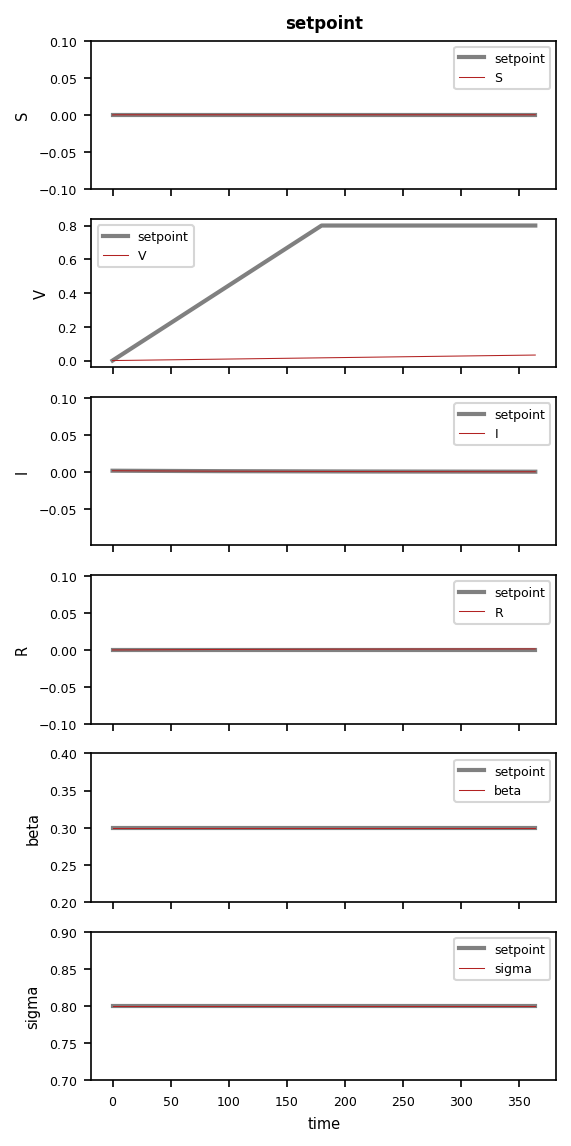

In [52]:
simulator.plot('setpoint')